<a href="https://colab.research.google.com/github/dan1esl/a3_dados_bigdata/blob/main/A3DADOS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install sqlalchemy psycopg2-binary -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 41.3 MB/s eta 0:00:00


In [3]:
import pandas as pd
import io
import os
import matplotlib.pyplot as plt
import numpy as np
import plotly.express as px
from plotly.io import show
import seaborn as sns
import sqlalchemy
import psycopg2

# Extração dos CSVs

In [6]:
def extract_twitch_data():
    with open("/content/Twitch_game_data.csv", "r", encoding="cp1252", errors="ignore") as f:
        linhas = f.readlines()
    linhas_limpas = []
    for linha in linhas:
        linha = linha.strip()
        if linha.startswith('"') and linha.endswith('"'):
            linha = linha[1:-1]
        linha = linha.replace('""', '"')
        linhas_limpas.append(linha)

    conteudo_csv = "\n".join(linhas_limpas)
    return pd.read_csv(io.StringIO(conteudo_csv), sep=',')

def extract_esports_data():
    with open("/content/HistoricalEsportData.csv", "r", encoding="cp1252", errors="ignore") as f:
        linhas = f.readlines()
    linhas_limpas = []
    for linha in linhas:
        linha = linha.strip()
        if linha.startswith('"') and linha.endswith('"'):
            linha = linha[1:-1]
        linha = linha.replace('""', '"')
        linhas_limpas.append(linha)

    conteudo_csv = "\n".join(linhas_limpas)
    return pd.read_csv(io.StringIO(conteudo_csv), sep=',')

def extract_games_data():
    return pd.read_csv("/content/Ultimate_Games_Dataset.csv", encoding="cp1252", encoding_errors="ignore")

def extract_all():
    print("Extraindo dados brutos dos datasets.")
    twitch = extract_twitch_data()
    esports = extract_esports_data()
    games = extract_games_data()
    print("Dados extraidos com sucesso.")
    return twitch, esports, games

twitch, esports, games = extract_all()

Extraindo dados brutos dos datasets.
Dados extraidos com sucesso.


# Normalização e tratamento dos dados

In [7]:
def transform_all(df_twitch, df_esports, df_games):
    print("Iniciando a padronização dos dados.")

    print("\nVerificação de valores nulos.")
    print("\nTwitch:")
    print(df_twitch.isnull().sum())

    print("\nEsports:")
    print(df_esports.isnull().sum())

    print("\nGames:")
    print(df_games.isnull().sum())

    df_twitch.columns = df_twitch.columns.str.strip().str.replace('"', '').str.replace("'", "")
    df_esports.columns = df_esports.columns.str.strip().str.replace('"', '').str.replace("'", "")
    df_games.columns = df_games.columns.str.strip().str.replace('"', '').str.replace("'", "")

    df_esports['Game'] = df_esports['Game'].str.strip().str.lower()
    df_games['title'] = df_games['title'].str.strip().str.lower()
    df_twitch['Game'] = df_twitch['Game'].str.strip().str.lower()

    df_esports['Date'] = pd.to_datetime(df_esports['Date'])
    df_esports['Year'] = df_esports['Date'].dt.year
    df_esports['Month'] = df_esports['Date'].dt.month

    df_twitch['Year'] = df_twitch['Year'].astype(int)
    df_twitch['Month'] = df_twitch['Month'].astype(int)
    df_esports['Year'] = df_esports['Year'].astype(int)
    df_esports['Month'] = df_esports['Month'].astype(int)

    print("Fazendo merge entre dados da Twitch e de Esports por jogo e data.")
    df_twitch_esports = pd.merge(
        df_twitch,
        df_esports,
        on=['Game','Year','Month'],
        how='inner'
    )
    print("Padronização da coluna Game.")
    df_final = pd.merge(
        df_twitch_esports,
        df_games,
        left_on='Game',
        right_on='title',
        how='left'
    )
    if 'title' in df_final.columns:
        df_final = df_final.drop(columns=['title'])

    print("Criando a variável gênero principal.")
    if 'all_genres' in df_final.columns:
      df_final['all_genres'] = df_final['all_genres'].fillna('Não Informado')
      df_final['genero_principal'] = df_final['all_genres'].str.split('|').str[0].str.strip()
    else:
        df_final['genero_principal'] = 'Não Informado'

    print("Corrigindo gêneros de jogos.")
    df_final.loc[(df_final['Game'] == 'fortnite') & (df_final['genero_principal'] == 'Não Informado'), 'genero_principal'] = 'Shooter'
    df_final.loc[(df_final['Game'] == 'league of legends: wild rift') & (df_final['genero_principal'] == 'Não Informado'), 'genero_principal'] = 'Moba'
    df_final.loc[(df_final['Game'] == 'arena of valor') & (df_final['genero_principal'] == 'Não Informado'), 'genero_principal'] = 'Moba'
    df_final.loc[(df_final['Game'] == 'naraka: bladepoint') & (df_final['genero_principal'] == 'Não Informado'), 'genero_principal'] = 'Action'
    df_final.loc[(df_final['Game'] == 'mobile legends: bang bang') & (df_final['genero_principal'] == 'Não Informado'), 'genero_principal'] = 'Moba'
    df_final.loc[df_final['Game'] == 'dota 2', 'genero_principal'] = 'Moba'
    df_final.loc[df_final['Game'] == 'league of legends', 'genero_principal'] = 'Moba'

    return df_final

df_final = transform_all(twitch, esports, games)

print("Total de registros.")
print(len(df_final))

print("\nRegistros sem correspondência.")
print(df_final['serial_no'].isnull().sum())

print("\nRegistros com correspondência.")
print(df_final['serial_no'].notnull().sum())

print("\nValores nulos após a transformação.")
print(df_final.isnull().sum())

print("\nValores duplicados.")
print(df_final.duplicated().sum())

Iniciando a padronização dos dados.

Verificação de valores nulos.

Twitch:
Rank                0
Game                1
Month               0
Year                0
Hours_watched       0
Hours_streamed      0
Peak_viewers        0
Peak_channels       0
Streamers           0
Avg_viewers         0
Avg_channels        0
Avg_viewer_ratio    0
dtype: int64

Esports:
Date           0
Game           0
Earnings       0
Players        0
Tournaments    0
dtype: int64

Games:
serial_no               0
game_id                 0
title                   0
release_date            0
release_year            0
all_genres              0
theme                   0
art_style               0
view_dimension          0
game_mode               0
is_multiplayer          0
controls                0
developers              0
publishers              0
all_platforms           0
platform_count          0
esrb_rating             0
user_rating           387
metacritic            886
ratings_count           0
reviews_cou

# Carregamento do dataset unificado no banco de dados.

In [8]:
import pandas as pd
import sqlalchemy


def load_data(df_final):
    print("Salvando CSV consolidado...")

    df_final.to_csv(
        "dados_unificados_esports.csv",
        index=False,
        encoding="utf-8-sig"
    )

    print("CSV salvo com sucesso!")

    print("Carregando os dados no banco...")

    USUARIO = 'postgres.afbjqfhptbsaijsqyckt'
    SENHA = 'SUA_SENHA'
    HOST = 'aws-1-us-east-2.pooler.supabase.com'
    PORTA = '5432'
    BANCO = 'postgres'

    try:
        conexao_url = (
            f"postgresql://{USUARIO}:{SENHA}"
            f"@{HOST}:{PORTA}/{BANCO}"
            "?sslmode=require"
        )

        print("Criando conexão...")
        engine = sqlalchemy.create_engine(
            conexao_url,
            pool_pre_ping=True
        )

        print("Enviando dados para o banco...")

        df_final.to_sql(
            name="dados_unificados_esports",
            con=engine,
            if_exists="replace",
            index=False,
            chunksize=1000,
            method="multi"
        )

        print("Dados carregados com sucesso!")

    except Exception as e:
        print(f"Erro ao carregar os dados no banco: {repr(e)}")


load_data(df_final)

Salvando CSV consolidado...
CSV salvo com sucesso!
Carregando os dados no banco...
Criando conexão...
Enviando dados para o banco...
Erro ao carregar os dados no banco: OperationalError('(psycopg2.OperationalError) connection to server at "aws-1-us-east-2.pooler.supabase.com" (13.58.13.125), port 5432 failed: FATAL:  password authentication failed for user "postgres"\n')


# Análise exploratória e descritiva.

## Análise da Média e Mediana por gênero principal e variação ao longo dos anos.

In [9]:
df_analise = df_final.copy()

df_analise['genero_principal'] = df_analise['genero_principal'].str.strip()
analise_generos = df_analise.loc[df_analise['genero_principal'] != 'Não Informado', 'genero_principal'].value_counts().nlargest(8).index
df_analise_filtrada = df_analise[df_analise['genero_principal'].isin(analise_generos)]

print('Análise de média e mediana de ganhos por gênero principal de jogo.')

analise_descritiva = df_analise_filtrada.groupby('genero_principal').agg(
    Quantidade_Registros=('Earnings', 'count'),
    Media_Ganhos_Dolar=('Earnings', 'mean'),
    Mediana_Ganhos_Dolar=('Earnings', 'median'),
).round(3)

display(analise_descritiva.style.format("${:,.2f}"))

Análise de média e mediana de ganhos por gênero principal de jogo.


,Quantidade_Registros,Media_Ganhos_Dolar,Mediana_Ganhos_Dolar
genero_principal,,,
Action,"$1,195.00","$207,011.25","$56,925.00"
Arcade,$79.00,"$3,451.10","$2,342.48"
Fighting,$88.00,"$41,694.53","$24,585.00"
Moba,$273.00,"$1,557,206.62","$516,346.85"
Shooter,$228.00,"$1,560,980.59","$963,169.04"
Simulation,$78.00,"$323,223.91","$66,536.95"
Sports,$173.00,"$358,145.80","$220,000.00"
Strategy,$261.00,"$211,787.33","$129,329.00"


In [10]:
df_media = df_analise_filtrada.groupby(['Year', 'genero_principal'])['Earnings'].mean().reset_index()

fig = px.line(
    df_media,
    x='Year',
    y='Earnings',
    color='genero_principal',
    markers=True,
    title='<b>Tendência Temporal: Evolução Média de Ganhos por Ano e Gênero</b>'
)

fig.update_layout(
    width=1100,
    height=480,
    xaxis_title='Ano',
    yaxis_title='Média de Ganhos',
    title_font_size=14,
    legend_title_text='Gênero Principal'
)

fig.show()

## Análise e visualização em gráficos do Desvio Padrão e Variação de Quartis por gênero principal.

Análise de desvio padrão e quartis por gênero principal de jogo.


,Desvio_Padrao_Ganhos,Quartil_1_Ganhos,Quartil_3_Ganhos
genero_principal,,,
Action,"$420,746.73","$12,401.80","$199,619.03"
Arcade,"$3,616.45","$1,395.00","$4,343.20"
Fighting,"$48,710.55","$12,177.66","$50,235.31"
Moba,"$4,317,280.29","$158,849.50","$1,402,860.00"
Shooter,"$2,834,184.90","$369,670.65","$2,167,419.56"
Simulation,"$548,331.23","$16,213.50","$440,664.56"
Sports,"$481,516.29","$60,669.11","$508,959.12"
Strategy,"$230,789.99","$32,398.58","$320,047.51"


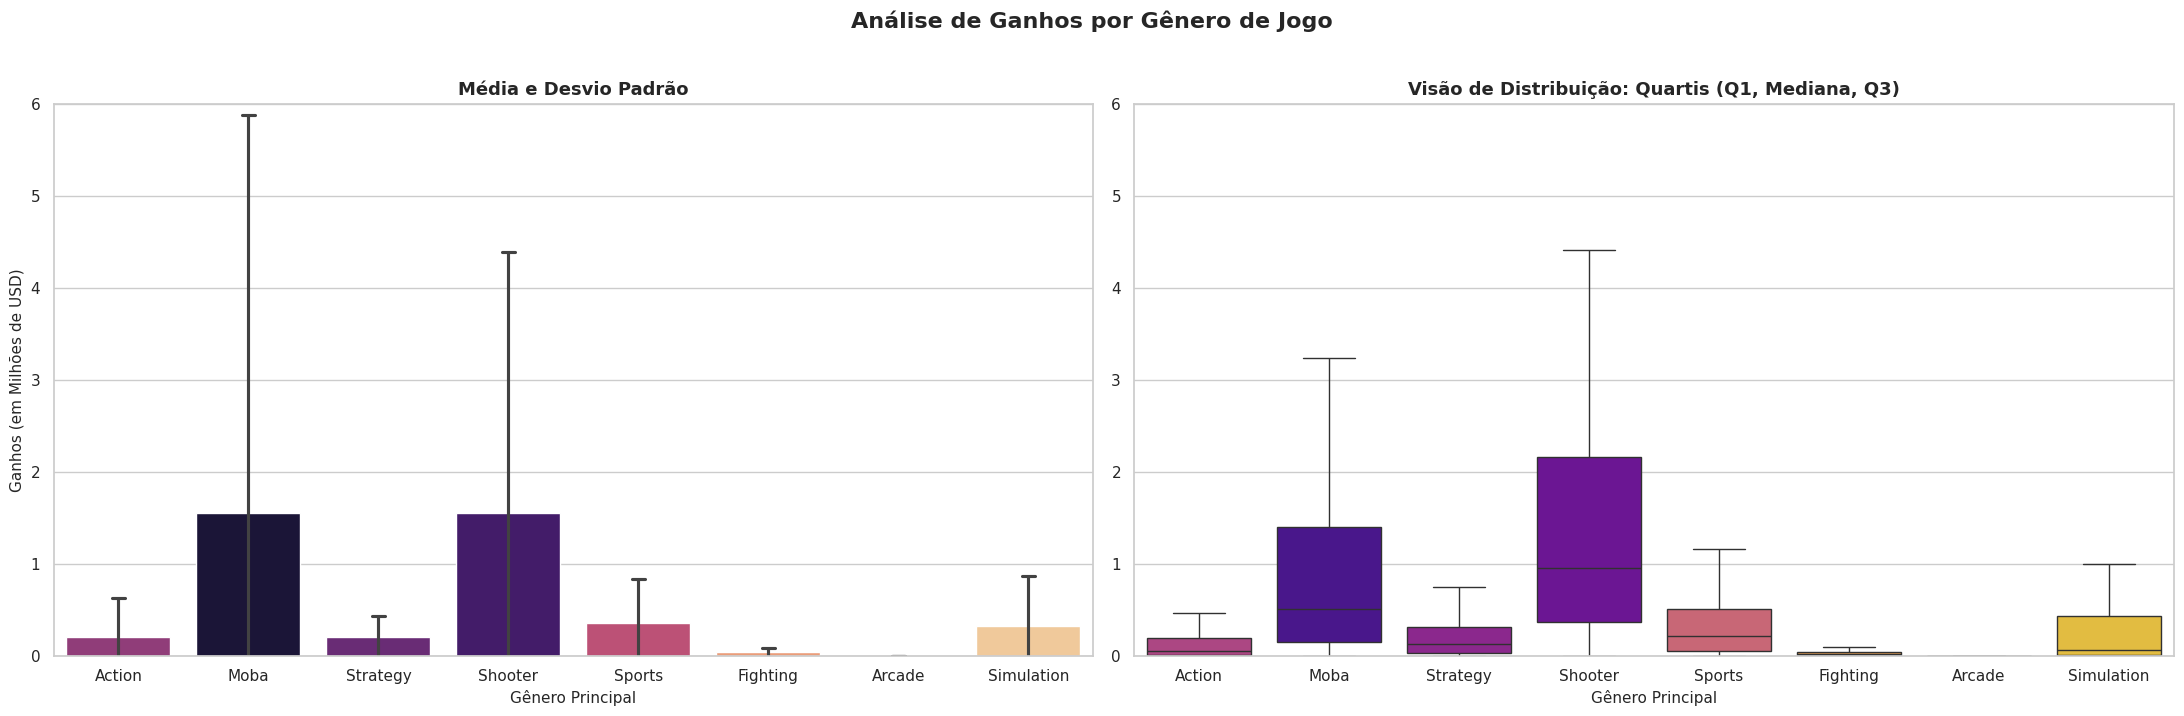

In [11]:
print('Análise de desvio padrão e quartis por gênero principal de jogo.')

analise_descritiva = df_analise_filtrada.groupby('genero_principal').agg(
    Desvio_Padrao_Ganhos=('Earnings', 'std'),
    Quartil_1_Ganhos=('Earnings', lambda x: x.quantile(0.25)),
    Quartil_3_Ganhos=('Earnings', lambda x: x.quantile(0.75))
)

display(analise_descritiva.style.format("${:,.2f}"))

sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(1, 2, figsize=(22, 7))

df_plot = df_analise_filtrada.assign(Earnings_M = df_analise_filtrada['Earnings'] / 1000000)

sns.barplot(
    data=df_plot,
    x='genero_principal',
    y='Earnings_M',
    hue='genero_principal',
    order=analise_generos,
    errorbar='sd',
    capsize=0.1,
    palette="magma",
    legend=False,
    ax=ax[0]
)
ax[0].set_title('Média e Desvio Padrão', fontsize=13, fontweight='bold')
ax[0].set_xlabel('Gênero Principal', fontsize=11)
ax[0].set_ylabel('Ganhos (em Milhões de USD)', fontsize=11)
ax[0].set_ylim(0, 6)

sns.boxplot(
    data=df_plot,
    x='genero_principal',
    y='Earnings_M',
    hue='genero_principal',
    order=analise_generos,
    palette="plasma",
    legend=False,
    ax=ax[1],
    showfliers=False
)
ax[1].set_title('Visão de Distribuição: Quartis (Q1, Mediana, Q3)', fontsize=13, fontweight='bold')
ax[1].set_xlabel('Gênero Principal', fontsize=11)
ax[1].set_ylabel('')
ax[1].set_ylim(0, 6)

plt.suptitle('Análise de Ganhos por Gênero de Jogo', fontsize=16, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

## Visualização da dispersão em ganhos por quartis.

In [12]:
print('Visualização dos quartis em gráfico.')

fig = px.box(
    df_analise_filtrada,
    x='genero_principal',
    y='Earnings',
    color='genero_principal',
    category_orders={'genero_principal': analise_generos},
    title='Visualização de outliers em ganhos.',

    hover_data=['genero_principal', 'Earnings', 'Game', 'Date'],
)

fig.update_layout(
    xaxis_title='Gênero Principal',
    yaxis_title='Ganhos em milhões',
    showlegend=False,
    template='plotly_white'
)

fig.show()

Visualização dos quartis em gráfico.


# Análise da média e mediana dos jogos mais assistidos.

In [13]:
df_media = df_analise_filtrada.groupby(['Year', 'genero_principal'])['Hours_watched'].mean().reset_index()

fig = px.line(
    df_media,
    x='Year',
    y='Hours_watched',
    color='genero_principal',
    markers=True,
    title='<b>Tendência Temporal: Evolução Média de Horas Assistidas por Gênero</b>'
)

fig.update_layout(
    width=1100,
    height=480,
    xaxis_title='Ano',
    yaxis_title='Horas Assistidas',
    title_font_size=14,
    legend_title_text='Gênero Principal'
)

fig.show()

## Visualização de outliers das horas assistidas por gênero de jogo.

In [14]:
print('Visualização dos quartis em gráfico.')

fig = px.box(
    df_analise_filtrada,
    x='genero_principal',
    y='Hours_watched',
    color='genero_principal',
    category_orders={'genero_principal': analise_generos},
    title='Visualização de outliers em horas assistidas.',

    hover_data=['genero_principal', 'Hours_watched', 'Game', 'Date'],
)

fig.update_layout(
    xaxis_title='Gênero Principal',
    yaxis_title='Horas assistidas em milhões',
    showlegend=False,
    template='plotly_white'
)

fig.show()

Visualização dos quartis em gráfico.
